In [1]:
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
import networkx as nx
import pandas as pd
from shapely.geometry import box

In [2]:
# Load the graph from an OSM XML file
graph = ox.graph_from_xml('raw_inputs/osm_map')

# Convert to GeoDataFrames for nodes and edges
nodes, edges = ox.graph_to_gdfs(graph)

nodes = nodes.reset_index(drop = False)
nodes = nodes.rename(columns = {'y': 'Latitude', 'x': 'Longitude'})

In [3]:
nodes

,osmid,Latitude,Longitude,highway,ref,geometry
0,7185334297,38.983628,-76.485890,NaN,NaN,POINT (-76.486 38.984)
1,7185334298,38.985016,-76.487252,NaN,NaN,POINT (-76.487 38.985)
2,7185334299,38.984730,-76.487104,NaN,NaN,POINT (-76.487 38.985)
3,7185334300,38.984248,-76.486876,NaN,NaN,POINT (-76.487 38.984)
4,7185334301,38.983553,-76.485975,NaN,NaN,POINT (-76.486 38.984)
...,...,...,...,...,...,...
2911,2637742276,38.986885,-76.458395,NaN,NaN,POINT (-76.458 38.987)
2912,102596476,38.980831,-76.501909,NaN,NaN,POINT (-76.502 38.981)
2913,102596478,38.982591,-76.500341,NaN,NaN,POINT (-76.5 38.983)
2914,2637742277,38.987030,-76.458357,NaN,NaN,POINT (-76.458 38.987)


In [4]:
edges

osmid  highway  oneway reversed  \
u          v          key                                                      
7185334297 7185334301 0                  769757600  footway   False    False   
           7185334305 0                  769757600  footway   False     True   
           3812745885 0                 1107988367  footway   False    False   
           3615416799 0    [377868379, 1107988367]  footway   False     True   
7185334298 7185334309 0                  769757597  service   False     True   
...                                            ...      ...     ...      ...   
2637742277 2637742276 1                  802161106      NaN   False     True   
2637742278 2637742281 0                   22814424      NaN   False    False   
                      1                  802161106      NaN   False    False   
           2637742277 0                   22814424      NaN   False     True   
                      1                  802161106      NaN   False     True   

                              length  \
u          v          key              
7185334297 7185334301 0    11.192553   
           7185334305 0    78.851539   
           3812745885 0    19.223154   
           3615416799 0    31.411890   
7185334298 7185334309 0    14.682692   
...                              ...   
2637742277 2637742276 1    16.483124   
2637742278 2637742281 0    20.060257   
                      1    20.060257   
           2637742277 0     7.227003   
                      1     7.227003   

                                                                    geometry  \
u          v          key                                                      
7185334297 7185334301 0          LINESTRING (-76.486 38.984, -76.486 38.984)   
           7185334305 0          LINESTRING (-76.486 38.984, -76.485 38.984)   
           3812745885 0          LINESTRING (-76.486 38.984, -76.486 38.984)   
           3615416799 0    LINESTRING (-76.486 38.984, -76.486 38.984, -7...   
7185334298 7185334309 0          LINESTRING (-76.487 38.985, -76.487 38.985)   
...                                                                      ...   
2637742277 2637742276 1          LINESTRING (-76.458 38.987, -76.458 38.987)   
2637742278 2637742281 0          LINESTRING (-76.458 38.987, -76.459 38.987)   
                      1          LINESTRING (-76.458 38.987, -76.459 38.987)   
           2637742277 0          LINESTRING (-76.458 38.987, -76.458 38.987)   
                      1          LINESTRING (-76.458 38.987, -76.458 38.987)   

                          name access service lanes maxspeed  ref bridge area  \
u          v          key                                                       
7185334297 7185334301 0    NaN    NaN     NaN   NaN      NaN  NaN    NaN  NaN   
           7185334305 0    NaN    NaN     NaN   NaN      NaN  NaN    NaN  NaN   
           3812745885 0    NaN    NaN     NaN   NaN      NaN  NaN    NaN  NaN   
           3615416799 0    NaN    NaN     NaN   NaN      NaN  NaN    NaN  NaN   
7185334298 7185334309 0    NaN    NaN     NaN   NaN      NaN  NaN    NaN  NaN   
...                        ...    ...     ...   ...      ...  ...    ...  ...   
2637742277 2637742276 1    NaN    NaN     NaN   NaN      NaN  NaN    NaN  NaN   
2637742278 2637742281 0    NaN    NaN     NaN   NaN      NaN  NaN    NaN  NaN   
                      1    NaN    NaN     NaN   NaN      NaN  NaN    NaN  NaN   
           2637742277 0    NaN    NaN     NaN   NaN      NaN  NaN    NaN  NaN   
                      1    NaN    NaN     NaN   NaN      NaN  NaN    NaN  NaN   

                          junction landuse tunnel  
u          v          key                          
7185334297 7185334301 0        NaN     NaN    NaN  
           7185334305 0        NaN     NaN    NaN  
           3812745885 0        NaN     NaN    NaN  
           3615416799 0        NaN     NaN    NaN  
7185334298 7185334309 0        NaN     NaN    NaN  
...                     

In [5]:
# Show the road types
edges['highway'].value_counts()

highway
footway                      1960
residential                  1184
service                       844
pedestrian                    350
secondary                     155
primary                        91
tertiary                       76
[steps, footway]               34
unclassified                   29
path                           28
steps                          18
corridor                       14
[residential, service]         10
[residential, footway]          6
[service, footway]              2
[construction, secondary]       2
track                           2
[residential, primary]          2
primary_link                    2
Name: count, dtype: int64

## Plot the graph network

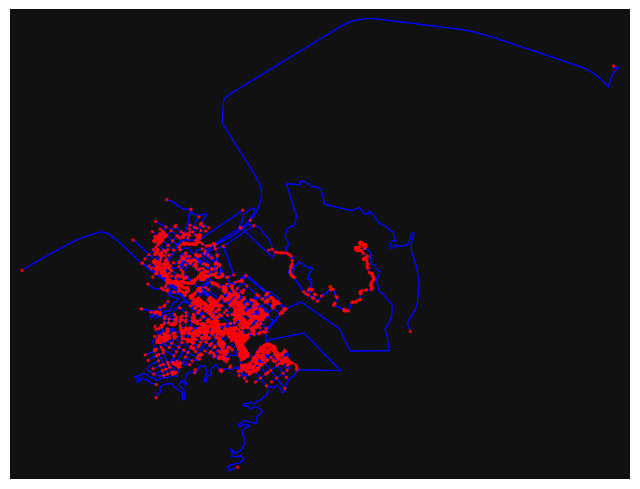

In [7]:
# Plot the graph
fig, ax = ox.plot_graph(graph, node_size=5, node_color='red', edge_linewidth=0.8, edge_color='blue')
plt.show()

## Try Clipping the Graph within the Bounding Box

In [9]:
# # Define your bounding box (latitude and longitude limits)
north, south, east, west = 38.9950, 38.9715, -76.4757, -76.5063
bbox = box(west, south, east, north)

# Get graph CRS
graph_crs = graph.graph["crs"]

In [10]:
# Reproject bounding box to graph CRS
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox], crs="EPSG:4326")
bbox_projected = bbox_gdf.to_crs(graph_crs)
bbox_polygon = bbox_projected.geometry.iloc[0]

# Clip the graph to the bounding box
graph_clipped = ox.truncate.truncate_graph_polygon(graph, polygon = bbox_polygon)

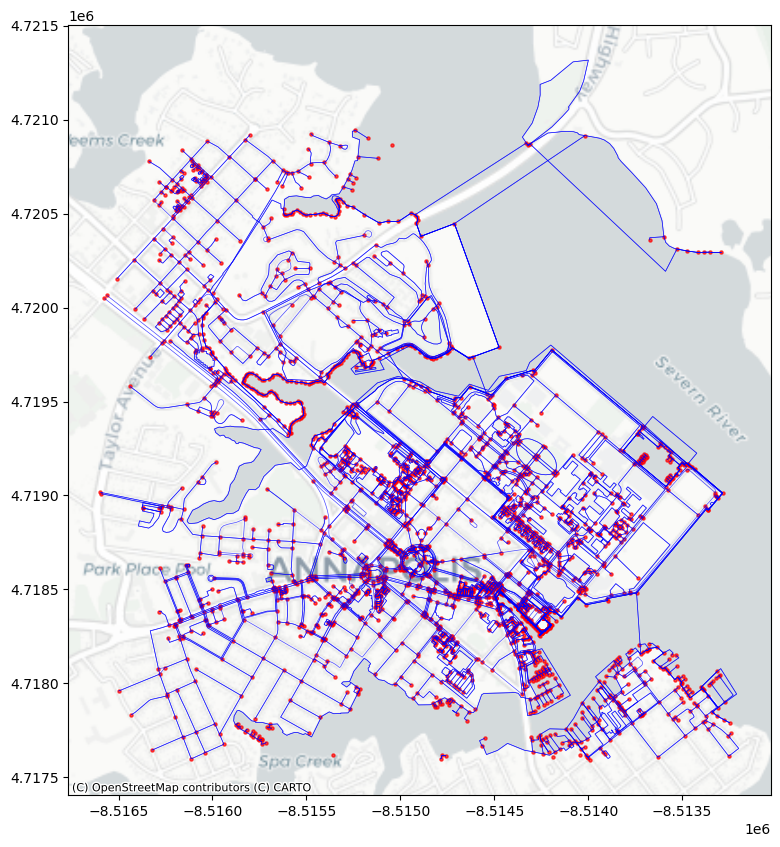

In [11]:
# Convert the clipped graph to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(graph_clipped)

# Reproject for the basemap
nodes = nodes.to_crs(epsg=3857)
edges = edges.to_crs(epsg=3857)

# Plot with basemap
fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, linewidth=0.5, edgecolor="blue", alpha=0.7)
nodes.plot(ax=ax, markersize=5, color="red", alpha=0.7)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=14)

plt.show()

The clipping is succesful, but there are clearly too many segments, so we need to further clean up the graph.

In [13]:
edges['highway'].value_counts(dropna = False)

highway
NaN                          4086
footway                      1960
residential                  1115
service                       815
pedestrian                    350
secondary                     149
primary                        89
tertiary                       74
[steps, footway]               34
unclassified                   29
path                           28
steps                          18
corridor                       14
[residential, service]         10
[residential, footway]          6
[service, footway]              2
[construction, secondary]       2
[residential, primary]          2
primary_link                    2
Name: count, dtype: int64

The wiki page containing definitions for the highway types is located here: https://wiki.openstreetmap.org/wiki/Key:highway. As per this page, paths classified under footway, steps, corridor, pedestrian, path can be safely ignored, as they are pedestrian paths only.

In [15]:
# Define the types of highways to remove
types_to_remove = ["footway", "steps", "corridor", "pedestrian", "path", ["footway", "steps"], 
                   "unclassified", "service", ["footway", "service"], ["service", "footway"], "Blank"]

# # Remove edges with specified highway types
# edges_to_remove = [
#     (u, v, k) for u, v, k, d in graph_clipped.edges(keys=True, data=True)
#     if d.get("highway") in types_to_remove]

# Remove edges with specified highway types or NaN values in highway
edges_to_remove = []
for u, v, k, data in graph_clipped.edges(keys=True, data=True):
    highway_value = data.get("highway", None)
    
    # Handle cases where 'highway' might be missing, NaN, or an unwanted type
    if highway_value is None:
        edges_to_remove.append((u, v, k))
    elif isinstance(highway_value, list):
        # If it's a list, check if any entry is NaN or in types_to_remove
        if any(pd.isna(item) or item in types_to_remove for item in highway_value):
            edges_to_remove.append((u, v, k))
    else:
        # Check single value for NaN or unwanted type
        if pd.isna(highway_value) or highway_value in types_to_remove:
            edges_to_remove.append((u, v, k))

graph_clipped.remove_edges_from(edges_to_remove)

In [16]:
# Identify and remove orphaned nodes (isolated nodes with no connections)
orphaned_nodes = list(nx.isolates(graph_clipped))
graph_clipped.remove_nodes_from(orphaned_nodes)

# Remove edges not connected to the main graph
# Find the largest connected component
largest_cc = max(nx.weakly_connected_components(graph_clipped), key=len)

# Create a subgraph with only the largest connected component
graph_clipped_cleaned = graph_clipped.subgraph(largest_cc).copy()

In [17]:
# Convert the filtered graph to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(graph_clipped_cleaned)

In [18]:
edges['highway'].value_counts(dropna = False)

highway
residential                  1013
secondary                     149
primary                        89
tertiary                       74
[construction, secondary]       2
[residential, primary]          2
primary_link                    2
Name: count, dtype: int64

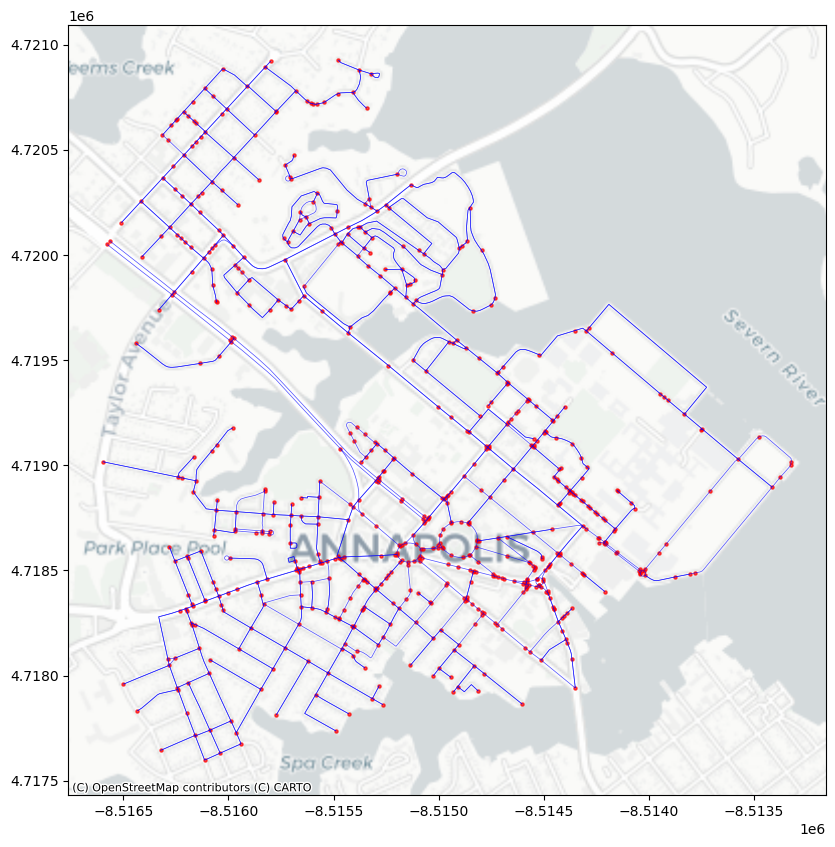

In [19]:
# Reproject for the basemap
nodes_plt = nodes.to_crs(epsg=3857)
edges_plt = edges.to_crs(epsg=3857)

# Plot with basemap
fig, ax = plt.subplots(figsize=(10, 10))
edges_plt.plot(ax=ax, linewidth=0.5, edgecolor="blue", alpha=0.7)
nodes_plt.plot(ax=ax, markersize=5, color="red", alpha=0.7)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=14)

plt.show()

In [20]:
nodes = nodes.rename(columns = {'y': 'Latitude', 'x': 'Longitude'})
edges['bridge'] = edges['bridge'].fillna('no')
nodes = nodes.reset_index()
edges = edges.reset_index()

In [21]:
# nodes.to_csv('Anapolis_OSM_Nodes.csv', index = None)
# edges.to_csv('Anapolis_OSM_Edges.csv', index = None)

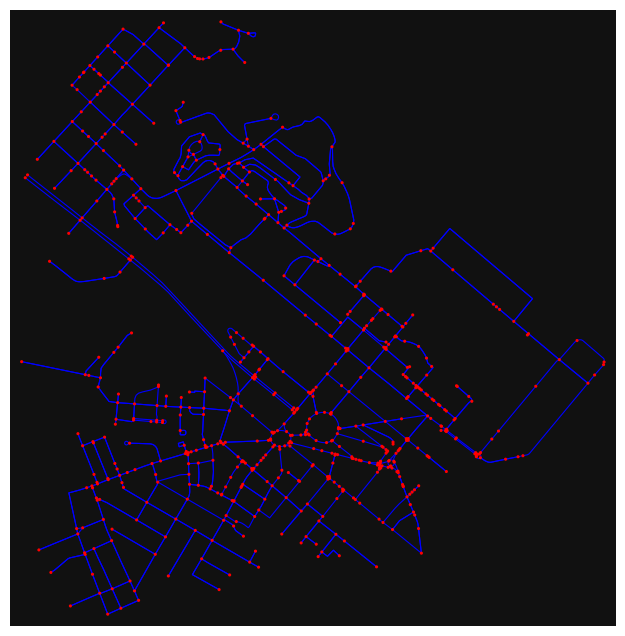

In [22]:
# Plot the graph
fig, ax = ox.plot_graph(graph_clipped_cleaned, node_size=5, node_color='red', edge_linewidth=0.8, edge_color='blue')
plt.show()

In [48]:
# Save the graph as Shapefiles
# ox.save_graph_shapefile(graph_clipped_cleaned, filepath="input_data")
# Save each to a shapefile via GeoPandas
nodes.to_file("input_data/nodes.shp")
edges.to_file("input_data/edges.shp")